In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
df = pd.read_csv('full_image_data_feb_25.csv')

In [3]:
books = pd.read_csv('full_book_data_feb_25.csv')

In [4]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [5]:
target_cks = [
 'CK_07 Spheres', 
 'CK_08 Spheres', 
 'CK_09 Spheres', 
 'CK_10 Spheres', 
 'CK_11 Spheres', 
 'CK_12 Spheres'
]

In [6]:
#filtering

#it is not a simple command as we need all 
#the cks that are in other rows with double images values
#to be included too

# Step 1: Filter the DataFrame for rows where 'cks' is in the target_cks list
filtered_df_target_cks = df[df['cks'].isin(target_cks)]

# Step 2: Get the unique 'images' values associated with the target cks
images_with_target_cks = filtered_df_target_cks['images'].unique()

# Step 3: Filter the original DataFrame to include all rows that have these images
filtered_df = df[df['images'].isin(images_with_target_cks)]

# filtered_df

In [7]:
unique_counts = pd.concat([
    df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('df'),
    filtered_df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('filtered_df')
], axis=1)

print(unique_counts)

                 df  filtered_df
images        20540          392
cluster_name   3563           63
cks             168           14
place            42           41
printer         166          159
publisher       155          149


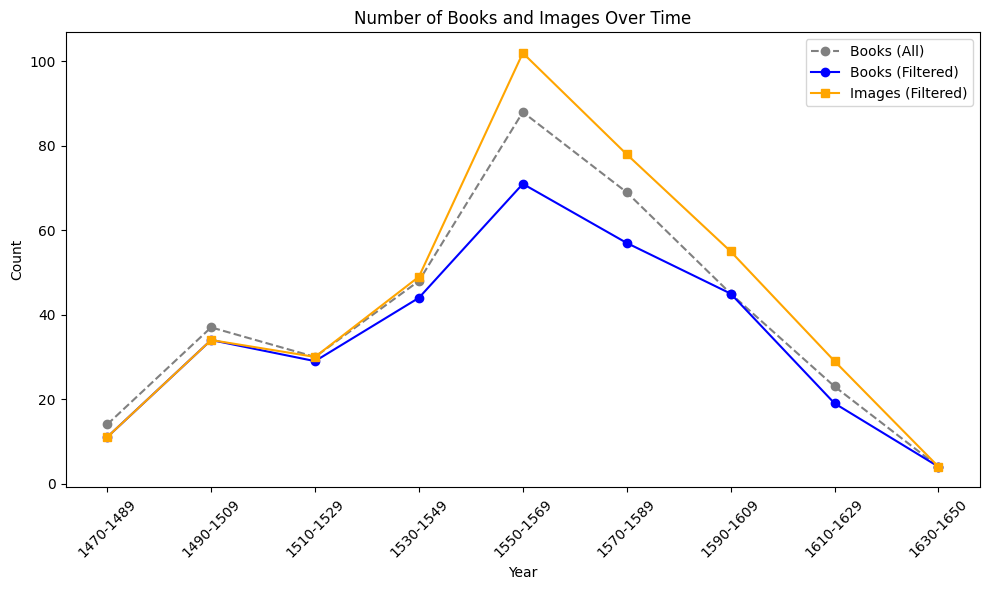

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Count number of books per year in full `books` DataFrame ---
books_per_year = books.groupby('year_interval', observed=False)['book'].nunique()

# --- 2. Count number of books per year in `filtered_df` ---
filtered_books_per_year = filtered_df.groupby('year_interval', observed=False)['book'].nunique()

# --- 3. Count number of images per year in `filtered_df` ---
images_per_year = filtered_df.groupby('year_interval', observed=False)['images'].nunique()

# Define the master timeline from `books` DataFrame
intervals = books_per_year.index.astype(str)

# Reindex to make sure all have the same timeline (fill missing with 0)
filtered_books_per_year = filtered_books_per_year.reindex(books_per_year.index, fill_value=0)
images_per_year = images_per_year.reindex(books_per_year.index, fill_value=0)

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Plot books from full books df
plt.plot(intervals, books_per_year.values, label='Books (All)', marker='o', linestyle='--', color='gray')

# Plot books from filtered_df
plt.plot(intervals, filtered_books_per_year.values, label='Books (Filtered)', marker='o', color='blue')

# Plot images from filtered_df
plt.plot(intervals, images_per_year.values, label='Images (Filtered)', marker='s', color='orange')

# Styling
plt.title('Number of Books and Images Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_books_vs_images_filtered.png', dpi=300)
plt.show()


Number of Unique Books per Content Group (CKs) over Time:
           CK_07 Spheres  CK_08 Spheres  CK_09 Spheres  CK_10 Spheres  \
1610-1629            3.0            0.0            2.0           11.0   
1470-1489            0.0            1.0           10.0            0.0   
1490-1509            0.0            4.0           30.0            0.0   
1510-1529            0.0            2.0           23.0            1.0   
1530-1549            0.0            3.0           10.0           31.0   
1550-1569            0.0            7.0            2.0           56.0   
1570-1589            0.0            2.0            2.0           43.0   
1630-1650            0.0            0.0            1.0            2.0   
1590-1609            0.0            0.0            0.0           25.0   

           CK_11 Spheres  CK_12 Spheres  Books  
1610-1629            4.0            2.0     14  
1470-1489            0.0            0.0     37  
1490-1509            0.0            0.0     30  
1510-1529      

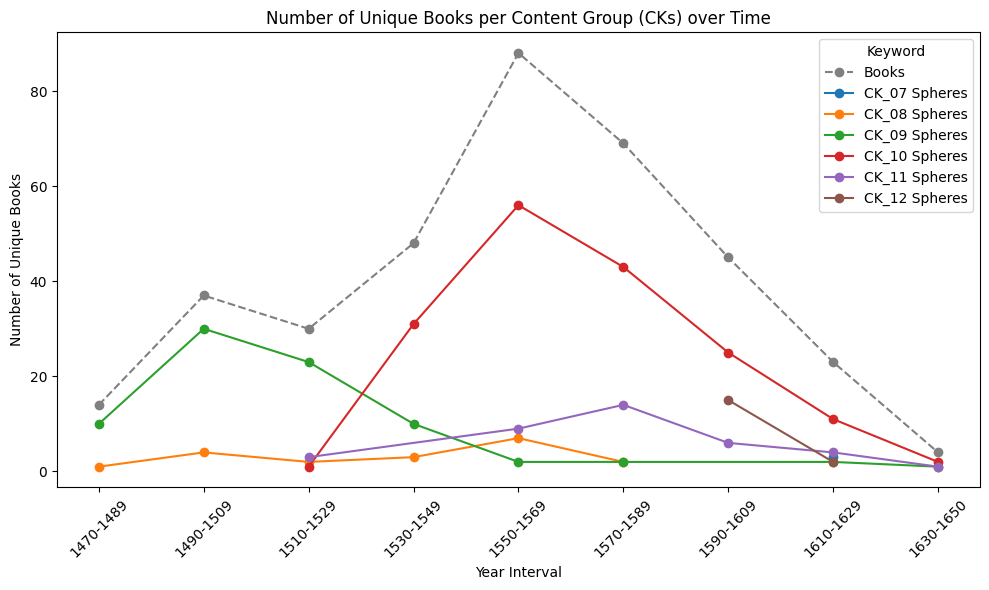

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Get unique books per year_interval
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Dictionary: {keyword: {interval: unique_book_count}}
book_counts = {
    keyword: (
        df[df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# Create a DataFrame for reporting if needed
book_counts_df = pd.DataFrame(book_counts).fillna(0)
book_counts_df['Books'] = unique_books_count.values

print("Number of Unique Books per Content Group (CKs) over Time:")
print(book_counts_df)

# Start plotting
plt.figure(figsize=(10, 6))

# Plot total books, skipping zero values
non_zero_books = [(interval, count) for interval, count in zip(unique_books_count.index, unique_books_count.values) if count > 0]
if non_zero_books:
    x_books, y_books = zip(*non_zero_books)
    plt.plot(x_books, y_books, marker='o', color='grey', linestyle='--', label='Books')

# Plot each keyword, skipping zero values
for keyword, data in book_counts.items():
    # Only keep intervals with count > 0
    non_zero_data = [(interval, count) for interval, count in data.items() if count > 0]
    if non_zero_data:
        x_kw, y_kw = zip(*non_zero_data)
        plt.plot(x_kw, y_kw, marker='o', label=keyword)

# Final touches
plt.title('Number of Unique Books per Content Group (CKs) over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Keyword')
plt.tight_layout()

# Save the figure if needed
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_books_per_ck_over_time_nonzero.png', dpi=300)

# Show the plot
plt.show()



=== Unique Image Counts per CK per Interval ===
               CK_07 Spheres  CK_08 Spheres  CK_09 Spheres  CK_10 Spheres  \
year_interval                                                               
1470-1489                  0              1             10              0   
1490-1509                  0              4             30              0   
1510-1529                  0              2             24              1   
1530-1549                  0              3             10             36   
1550-1569                  0              8              2             83   
1570-1589                  0              2              4             58   
1590-1609                  0              0              0             31   
1610-1629                  3              0              2             16   
1630-1650                  0              0              1              2   

               CK_11 Spheres  CK_12 Spheres  
year_interval                                
1470-1489  

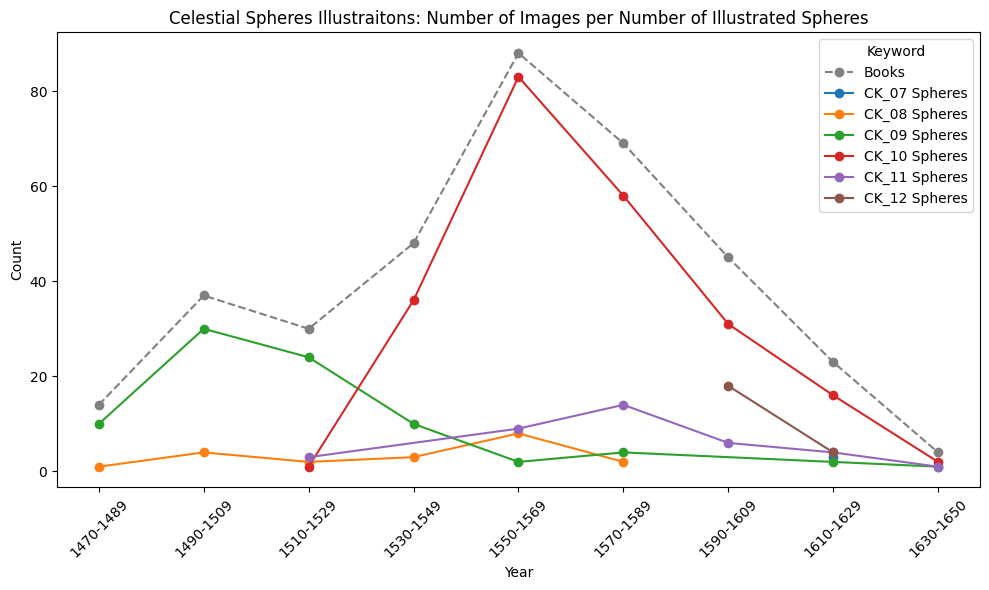

In [25]:
#plot number of images over time from the target cks

# Get unique books per year_interval
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Define the master timeline from book data
intervals = unique_books_count.index.astype(str)

# Dictionary: {keyword: {interval: unique_image_count}}
counts = {
    keyword: (
        df[df['cks'] == keyword]
        .groupby('year_interval', observed=False)['images']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# Create a DataFrame for tabular display (fills in 0 for missing intervals)
counts_table = pd.DataFrame(counts, index=unique_books_count.index).fillna(0).astype(int)
print("\n=== Unique Image Counts per CK per Interval ===")
print(counts_table)

# Start plotting
plt.figure(figsize=(10, 6))

# Plot books
plt.plot(intervals, unique_books_count.values, label='Books', marker='o', color='grey', linestyle='--')

# Plot each keyword (excluding zero values from the line)
for keyword in target_cks:
    data = counts.get(keyword, {})
    keyword_values = [data.get(interval, 0) for interval in unique_books_count.index]
    non_zero_intervals = [intervals[i] for i, val in enumerate(keyword_values) if val > 0]
    non_zero_values = [val for val in keyword_values if val > 0]
    
    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# Final touches
plt.title('Celestial Spheres Illustraitons: Number of Images per Number of Illustrated Spheres')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Keyword')
plt.tight_layout()

# Save the plot
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_celstial_spheres_imaages_per_cks.png', dpi=300)
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_3959/2023932101.py:84: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_num_spheres_printer_network.png', dpi=300)
/Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


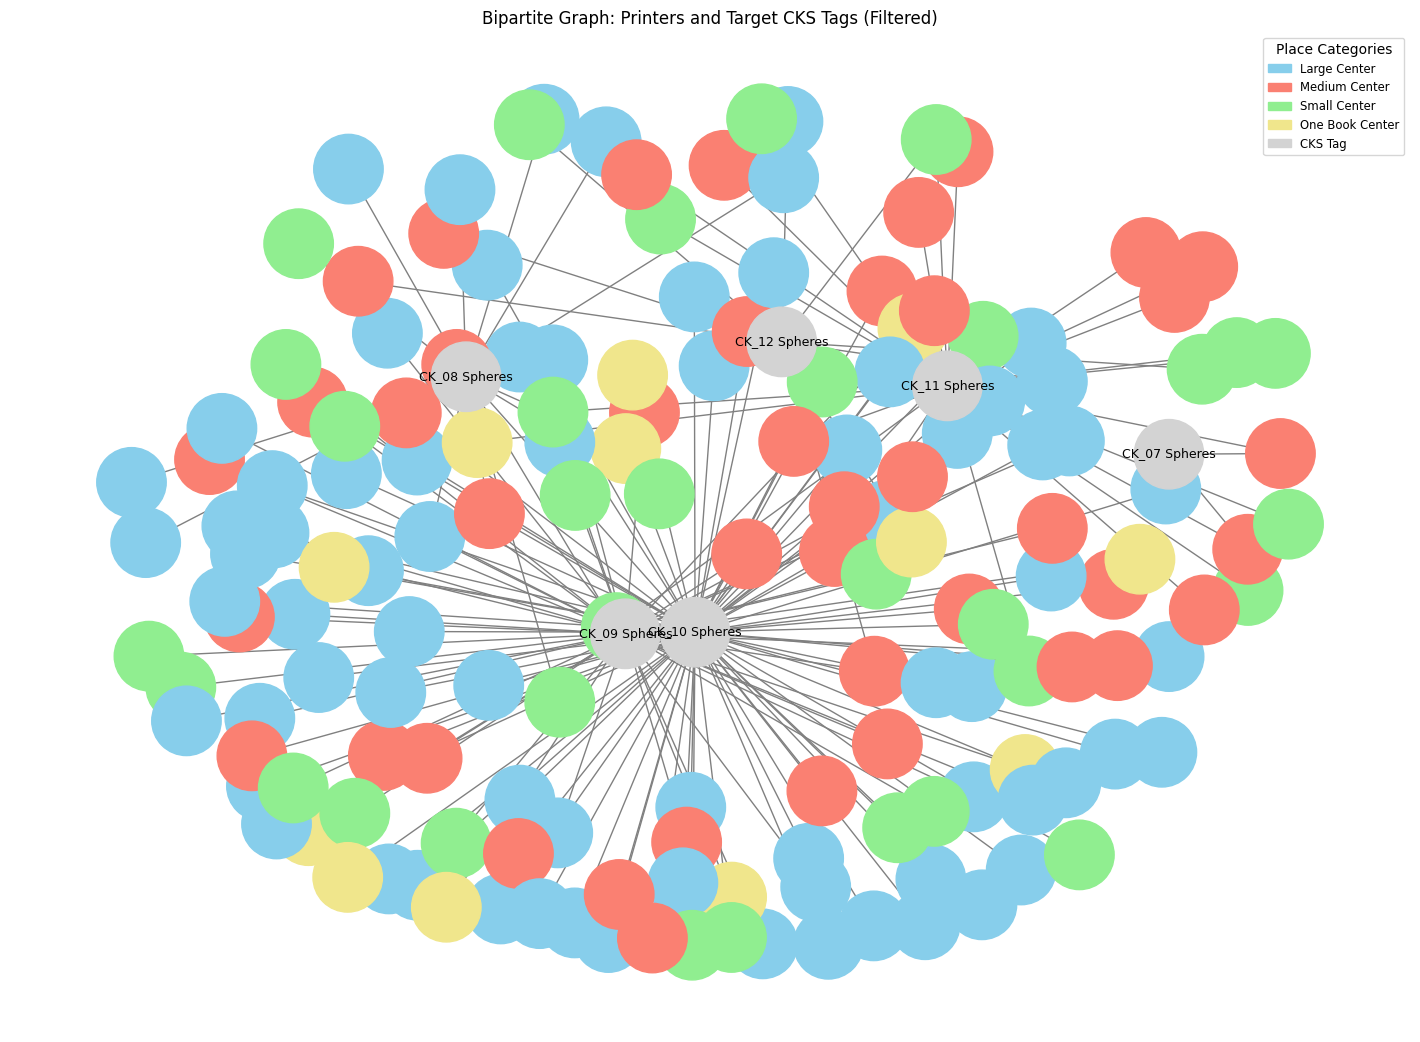

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === PARAMETERS ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}

# === STEP 1: FILTER TO TARGET CKS ===
subset_df = filtered_df[filtered_df['cks'].isin(target_cks)].copy()

# Define nodes
places = subset_df['printer'].dropna().unique().tolist()
cks_tags = subset_df['cks'].dropna().unique().tolist()  # Subset of target_cks

# === STEP 2: BUILD EDGE LIST ===
edges = []

for place in places:
    place_data = subset_df[subset_df['printer'] == place]
    for cks in cks_tags:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

edges_df = pd.DataFrame(edges, columns=['printer', 'cks']).drop_duplicates()

# === STEP 3: ASSIGN COLORS TO PRINTERS ===
place_color_map = {
    place: category_color_map.get(
        filtered_df[filtered_df['printer'] == place]['place_category'].iloc[0],
        'gray'
    )
    for place in places
}

# === STEP 4: BUILD GRAPH ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(cks_tags, bipartite=1)
G.add_edges_from(edges_df.itertuples(index=False, name=None))

# Node colors
node_colors = [
    place_color_map.get(node, 'gray') if node in places else 'lightgray'
    for node in G.nodes()
]

# Label only CKS nodes
labels = {node: node for node in cks_tags}

# === STEP 5: PLOT GRAPH ===
plt.figure(figsize=(14, 10), constrained_layout=True)

pos = nx.spring_layout(G, seed=42, k=0.5)

nx.draw(
    G, pos,
    labels=labels,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# Legend
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='lightgray', label='CKS Tag'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Printers and Target CKS Tags (Filtered)")
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_num_spheres_printer_network.png', dpi=300)
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_3959/4185020271.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


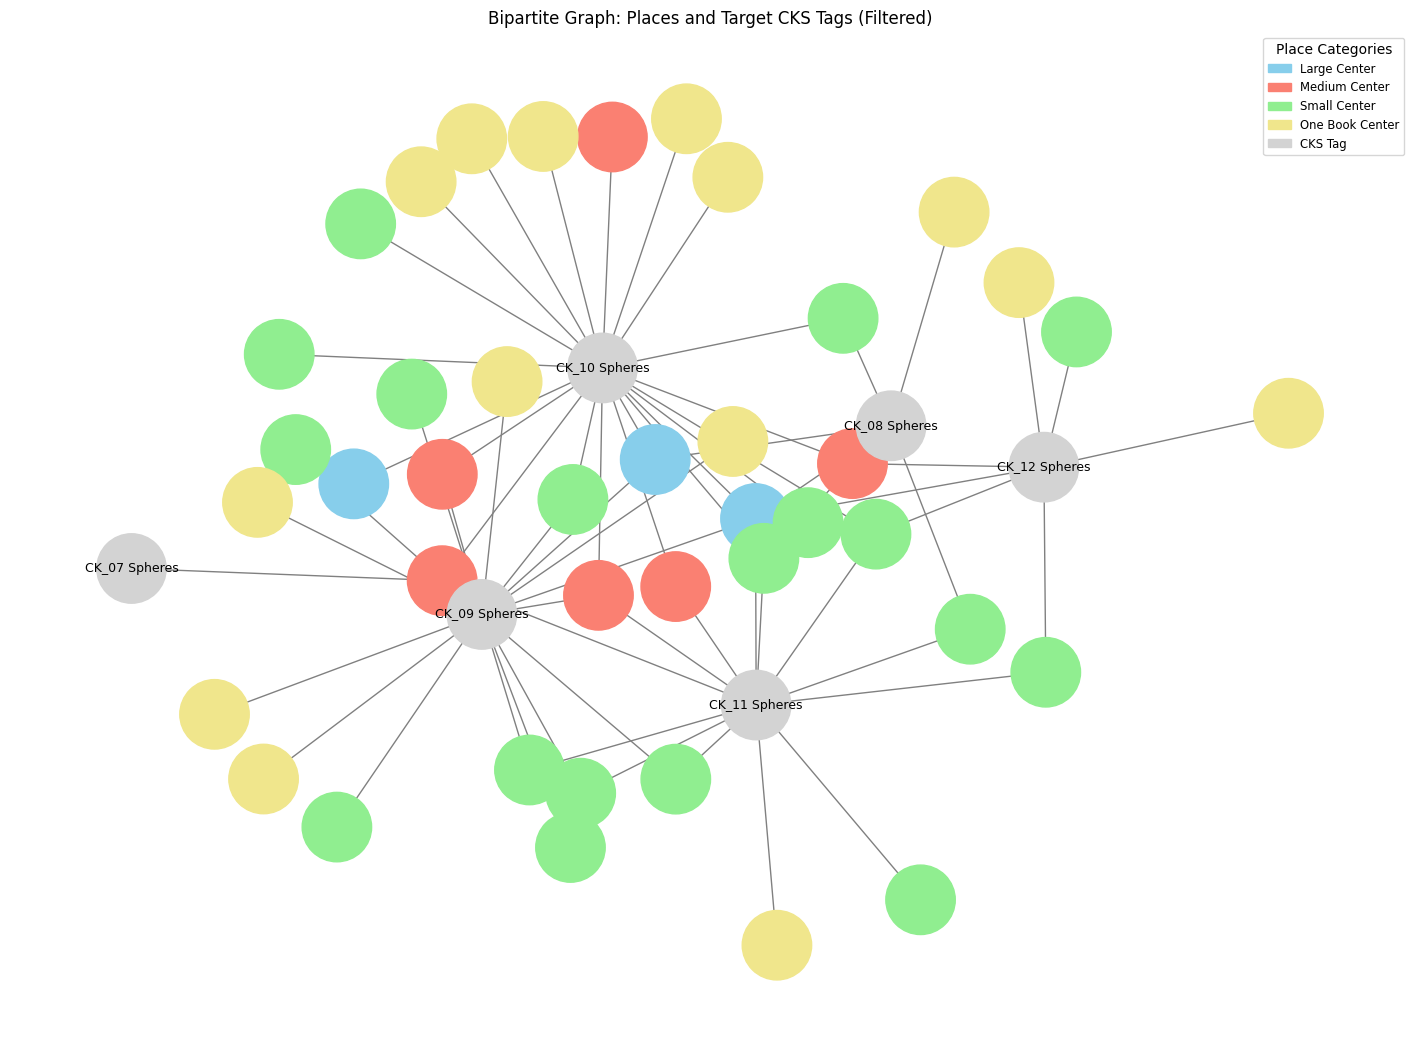

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === PARAMETERS ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}

# === STEP 1: FILTER TO TARGET CKS ===
subset_df = filtered_df[filtered_df['cks'].isin(target_cks)].copy()

# Define nodes: places and target CKS tags
places = subset_df['place'].dropna().unique().tolist()
cks_tags = subset_df['cks'].dropna().unique().tolist()  # Subset of target_cks

# === STEP 2: BUILD EDGE LIST ===
edges = []

for place in places:
    place_data = subset_df[subset_df['place'] == place]
    for cks in cks_tags:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

edges_df = pd.DataFrame(edges, columns=['place', 'cks']).drop_duplicates()

# === STEP 3: ASSIGN COLORS TO PLACES ===
place_color_map = {
    place: category_color_map.get(
        filtered_df[filtered_df['place'] == place]['place_category'].iloc[0],
        'gray'
    )
    for place in places
}

# === STEP 4: BUILD GRAPH ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(cks_tags, bipartite=1)
G.add_edges_from(edges_df.itertuples(index=False, name=None))

# Assign node colors
node_colors = [
    place_color_map.get(node, 'gray') if node in places else 'lightgray'
    for node in G.nodes()
]

# Labels only for CKS tags
labels = {node: node for node in cks_tags}

# === STEP 5: PLOT ===
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.5)

nx.draw(
    G, pos,
    labels=labels,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# Legend
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='lightgray', label='CKS Tag'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Places and Target CKS Tags (Filtered)")
plt.tight_layout()
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_num_spheres_places.png', dpi=300)
plt.show()


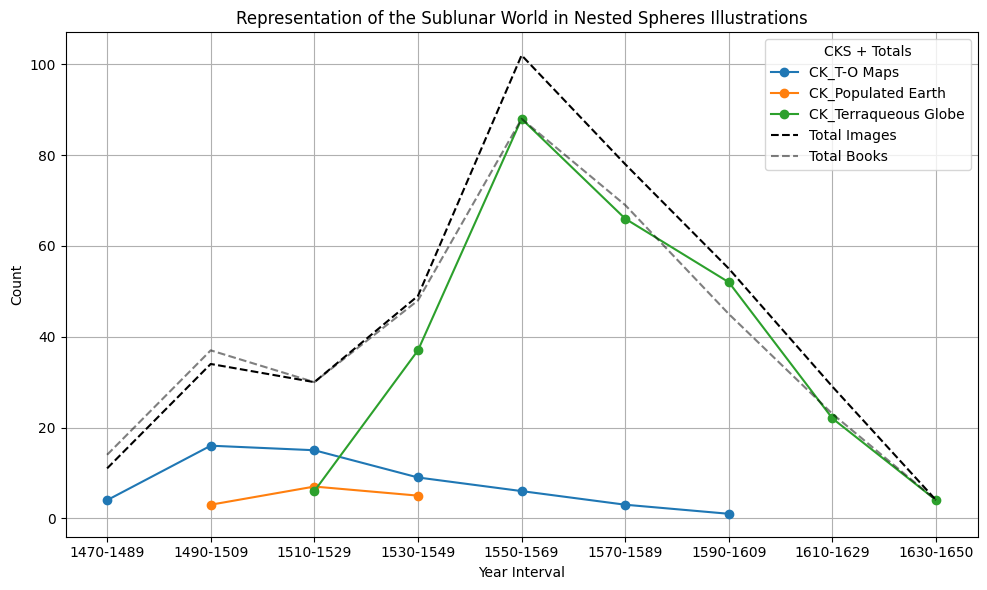

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Define your keywords (cks values)
keywords = ['CK_T-O Maps', 'CK_Populated Earth', 'CK_Terraqueous Globe']

plt.figure(figsize=(10, 6))

# Plot per-CKS line
for cks_value in keywords:
    subset = filtered_df[filtered_df['cks'] == cks_value]
    grouped = subset.groupby('year_interval')['images'].nunique()
    plt.plot(grouped.index, grouped.values, marker='o', label=cks_value)

# --- Add broken black line: total unique images per year_interval ---
total_images = filtered_df.groupby('year_interval')['images'].nunique()
plt.plot(total_images.index, total_images.values, linestyle='--', color='black', label='Total Images')

# --- Add broken black line: total books per year_interval from books df ---
# Assuming 'books' has columns 'year_interval' and 'book'
total_books = books.groupby('year_interval')['book'].count()
plt.plot(total_books.index, total_books.values, linestyle='--', color='black', label='Total Books', alpha=0.5)

# Plot styling
plt.title('Representation of the Sublunar World in Nested Spheres Illustrations')
plt.xlabel('Year Interval')
plt.ylabel('Count')
plt.legend(title='CKS + Totals')
plt.grid(True)
plt.tight_layout()

plt.savefig("/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_nested_spheres_rep_sublunar.png", dpi=300)

plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_3959/1868315812.py:87: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_nested_spheres_sublunar_rep_network.png', dpi=300)
/Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


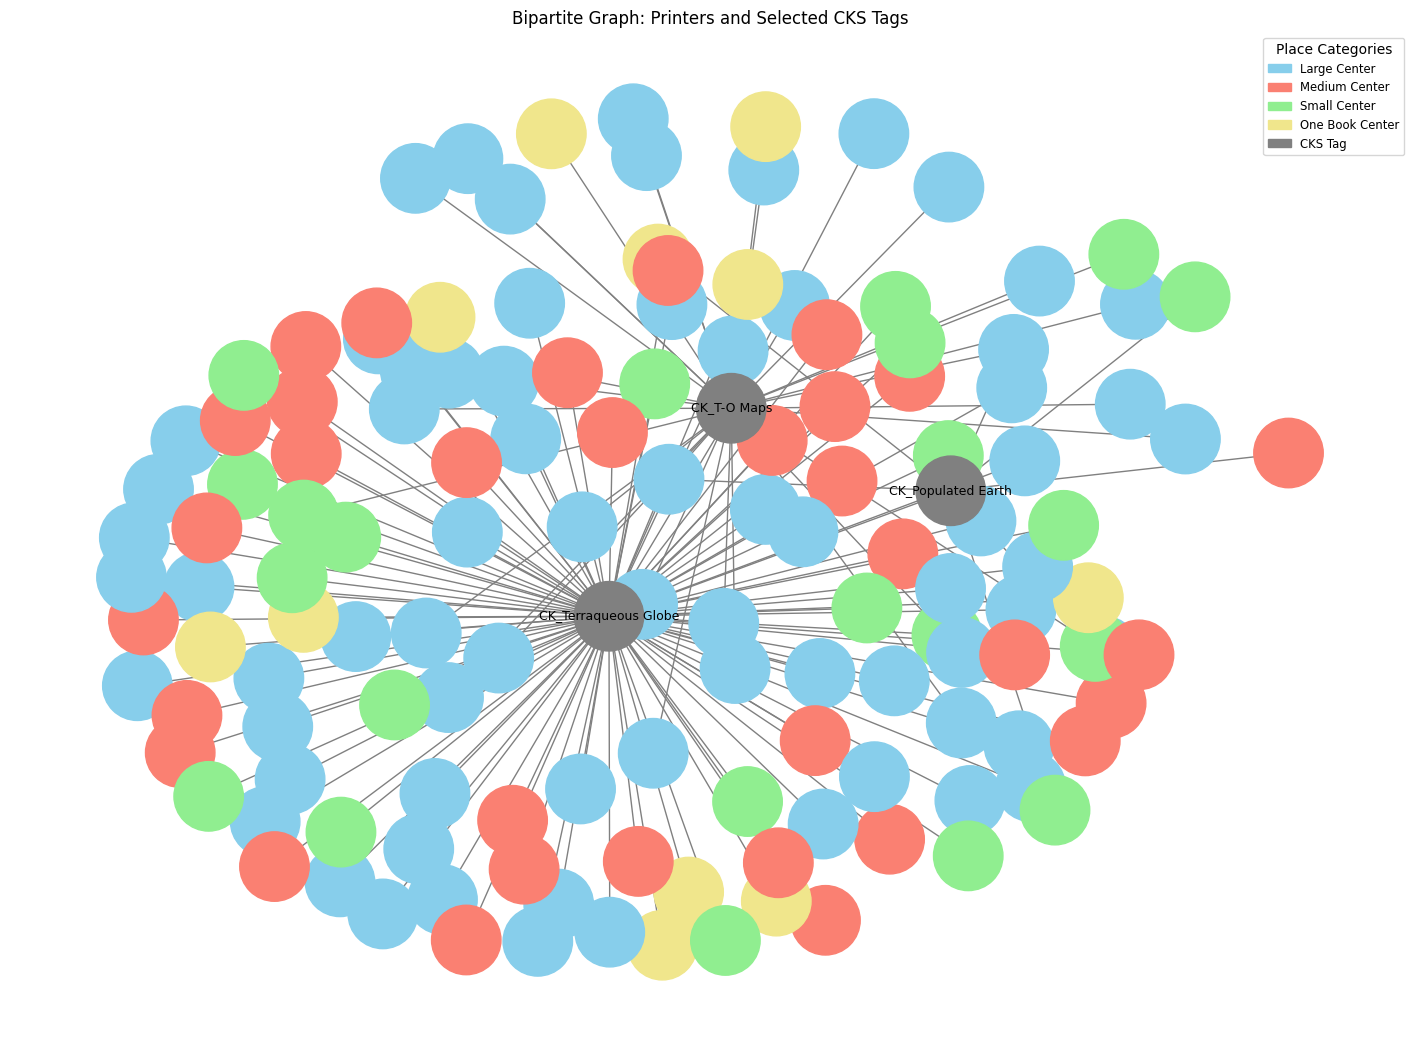

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === PARAMETERS ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}

# === DEFINE THE NEW CKS VALUES TO USE ===
keywords = ['CK_T-O Maps', 'CK_Populated Earth', 'CK_Terraqueous Globe']

# === STEP 1: FILTER TO JUST THOSE CKS ===
subset_df = filtered_df[filtered_df['cks'].isin(keywords)].copy()

# Define nodes
places = subset_df['printer'].dropna().unique().tolist()
cks_tags = subset_df['cks'].dropna().unique().tolist()  # This will just be the keywords

# === STEP 2: BUILD EDGE LIST ===
edges = []

for place in places:
    place_data = subset_df[subset_df['printer'] == place]
    for cks in cks_tags:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

edges_df = pd.DataFrame(edges, columns=['printer', 'cks']).drop_duplicates()

# === STEP 3: ASSIGN COLORS TO PRINTERS ===
place_color_map = {
    place: category_color_map.get(
        filtered_df[filtered_df['printer'] == place]['place_category'].iloc[0],
        'gray'
    )
    for place in places
}

# === STEP 4: BUILD GRAPH ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)     # Printers
G.add_nodes_from(cks_tags, bipartite=1)   # Selected CKS tags
G.add_edges_from(edges_df.itertuples(index=False, name=None))

# === STEP 5: NODE COLORS ===
node_colors = [
    place_color_map.get(node, 'gray') if node in places else 'gray'
    for node in G.nodes()
]

# Label only CKS nodes
labels = {node: node for node in cks_tags}

# === STEP 6: PLOT GRAPH ===
plt.figure(figsize=(14, 10), constrained_layout=True)

pos = nx.spring_layout(G, seed=42, k=0.5)

nx.draw(
    G, pos,
    labels=labels,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# === LEGEND ===
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='gray', label='CKS Tag'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Printers and Selected CKS Tags")
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_nested_spheres_sublunar_rep_network.png', dpi=300)
plt.show()


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_3959/4057336521.py:87: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_nested_spheres_sublunar_rep_place_network.png', dpi=300)


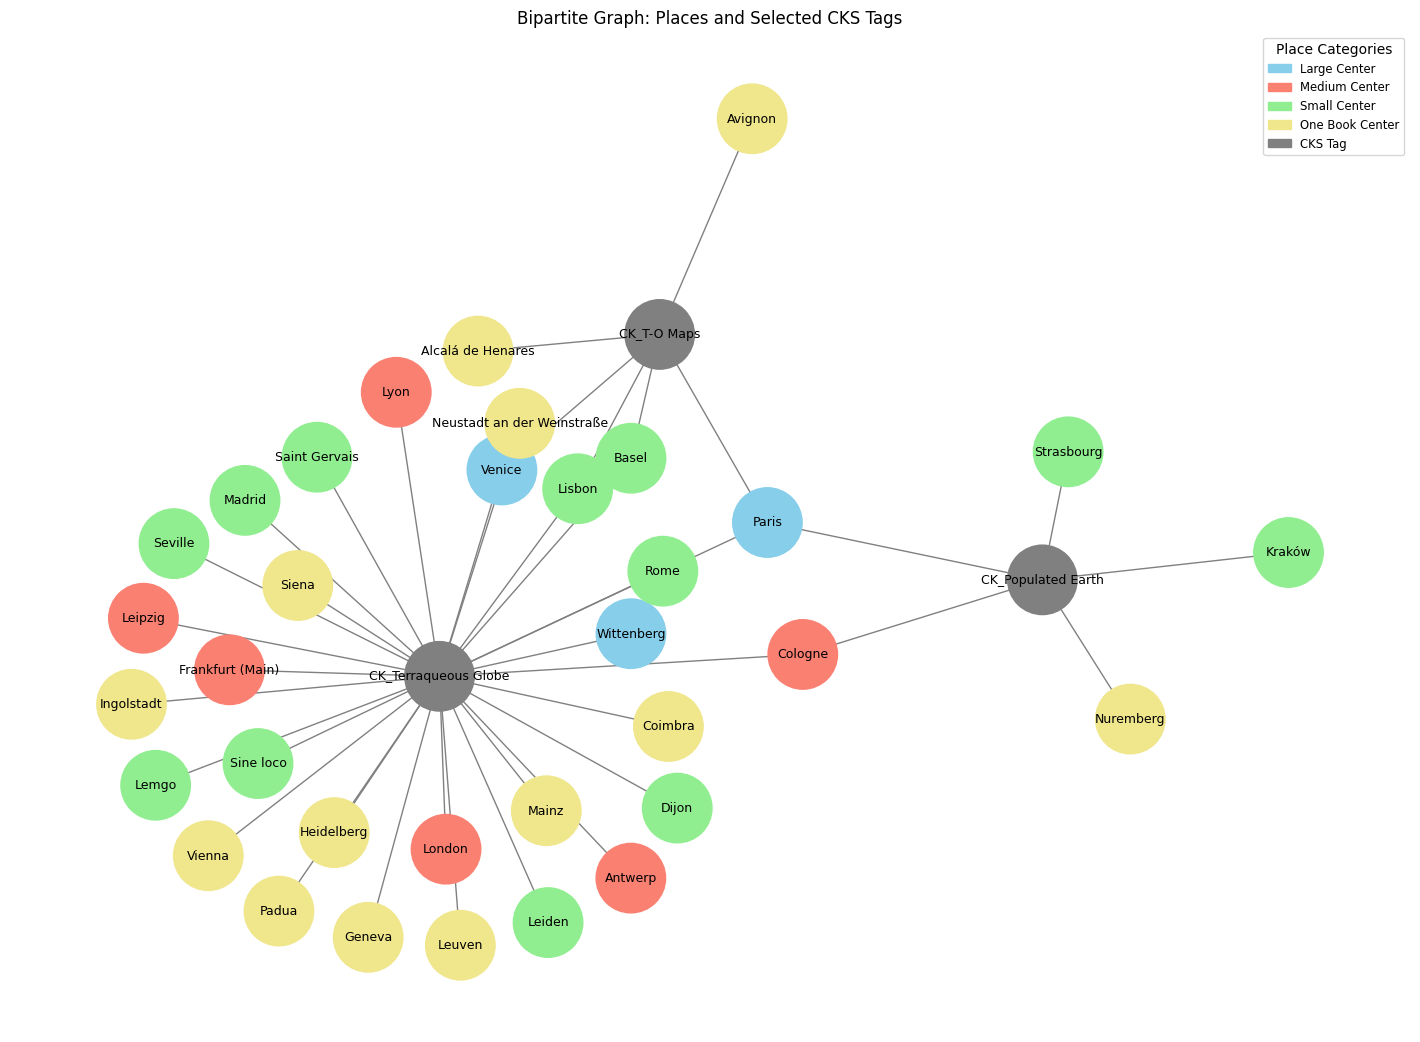

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === PARAMETERS ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}

# === DEFINE THE NEW CKS VALUES TO USE ===
keywords = ['CK_T-O Maps', 'CK_Populated Earth', 'CK_Terraqueous Globe']

# === STEP 1: FILTER TO JUST THOSE CKS ===
subset_df = filtered_df[filtered_df['cks'].isin(keywords)].copy()

# Define nodes
places = subset_df['place'].dropna().unique().tolist()
cks_tags = subset_df['cks'].dropna().unique().tolist()

# === STEP 2: BUILD EDGE LIST ===
edges = []

for place in places:
    place_data = subset_df[subset_df['place'] == place]
    for cks in cks_tags:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

edges_df = pd.DataFrame(edges, columns=['place', 'cks']).drop_duplicates()

# === STEP 3: ASSIGN COLORS TO PLACES ===
place_color_map = {
    place: category_color_map.get(
        filtered_df[filtered_df['place'] == place]['place_category'].iloc[0],
        'gray'
    )
    for place in places
}

# === STEP 4: BUILD GRAPH ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)     # Places
G.add_nodes_from(cks_tags, bipartite=1)   # Selected CKS tags
G.add_edges_from(edges_df.itertuples(index=False, name=None))

# === STEP 5: NODE COLORS ===
node_colors = [
    place_color_map.get(node, 'gray') if node in places else 'gray'
    for node in G.nodes()
]

# Label both places and CKS nodes
labels = {node: node for node in G.nodes()}

# === STEP 6: PLOT GRAPH ===
plt.figure(figsize=(14, 10), constrained_layout=True)

pos = nx.spring_layout(G, seed=42, k=0.5)

nx.draw(
    G, pos,
    labels=labels,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# === LEGEND ===
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='gray', label='CKS Tag'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.title("Bipartite Graph: Places and Selected CKS Tags")
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_nested_spheres_sublunar_rep_place_network.png', dpi=300)
plt.show()


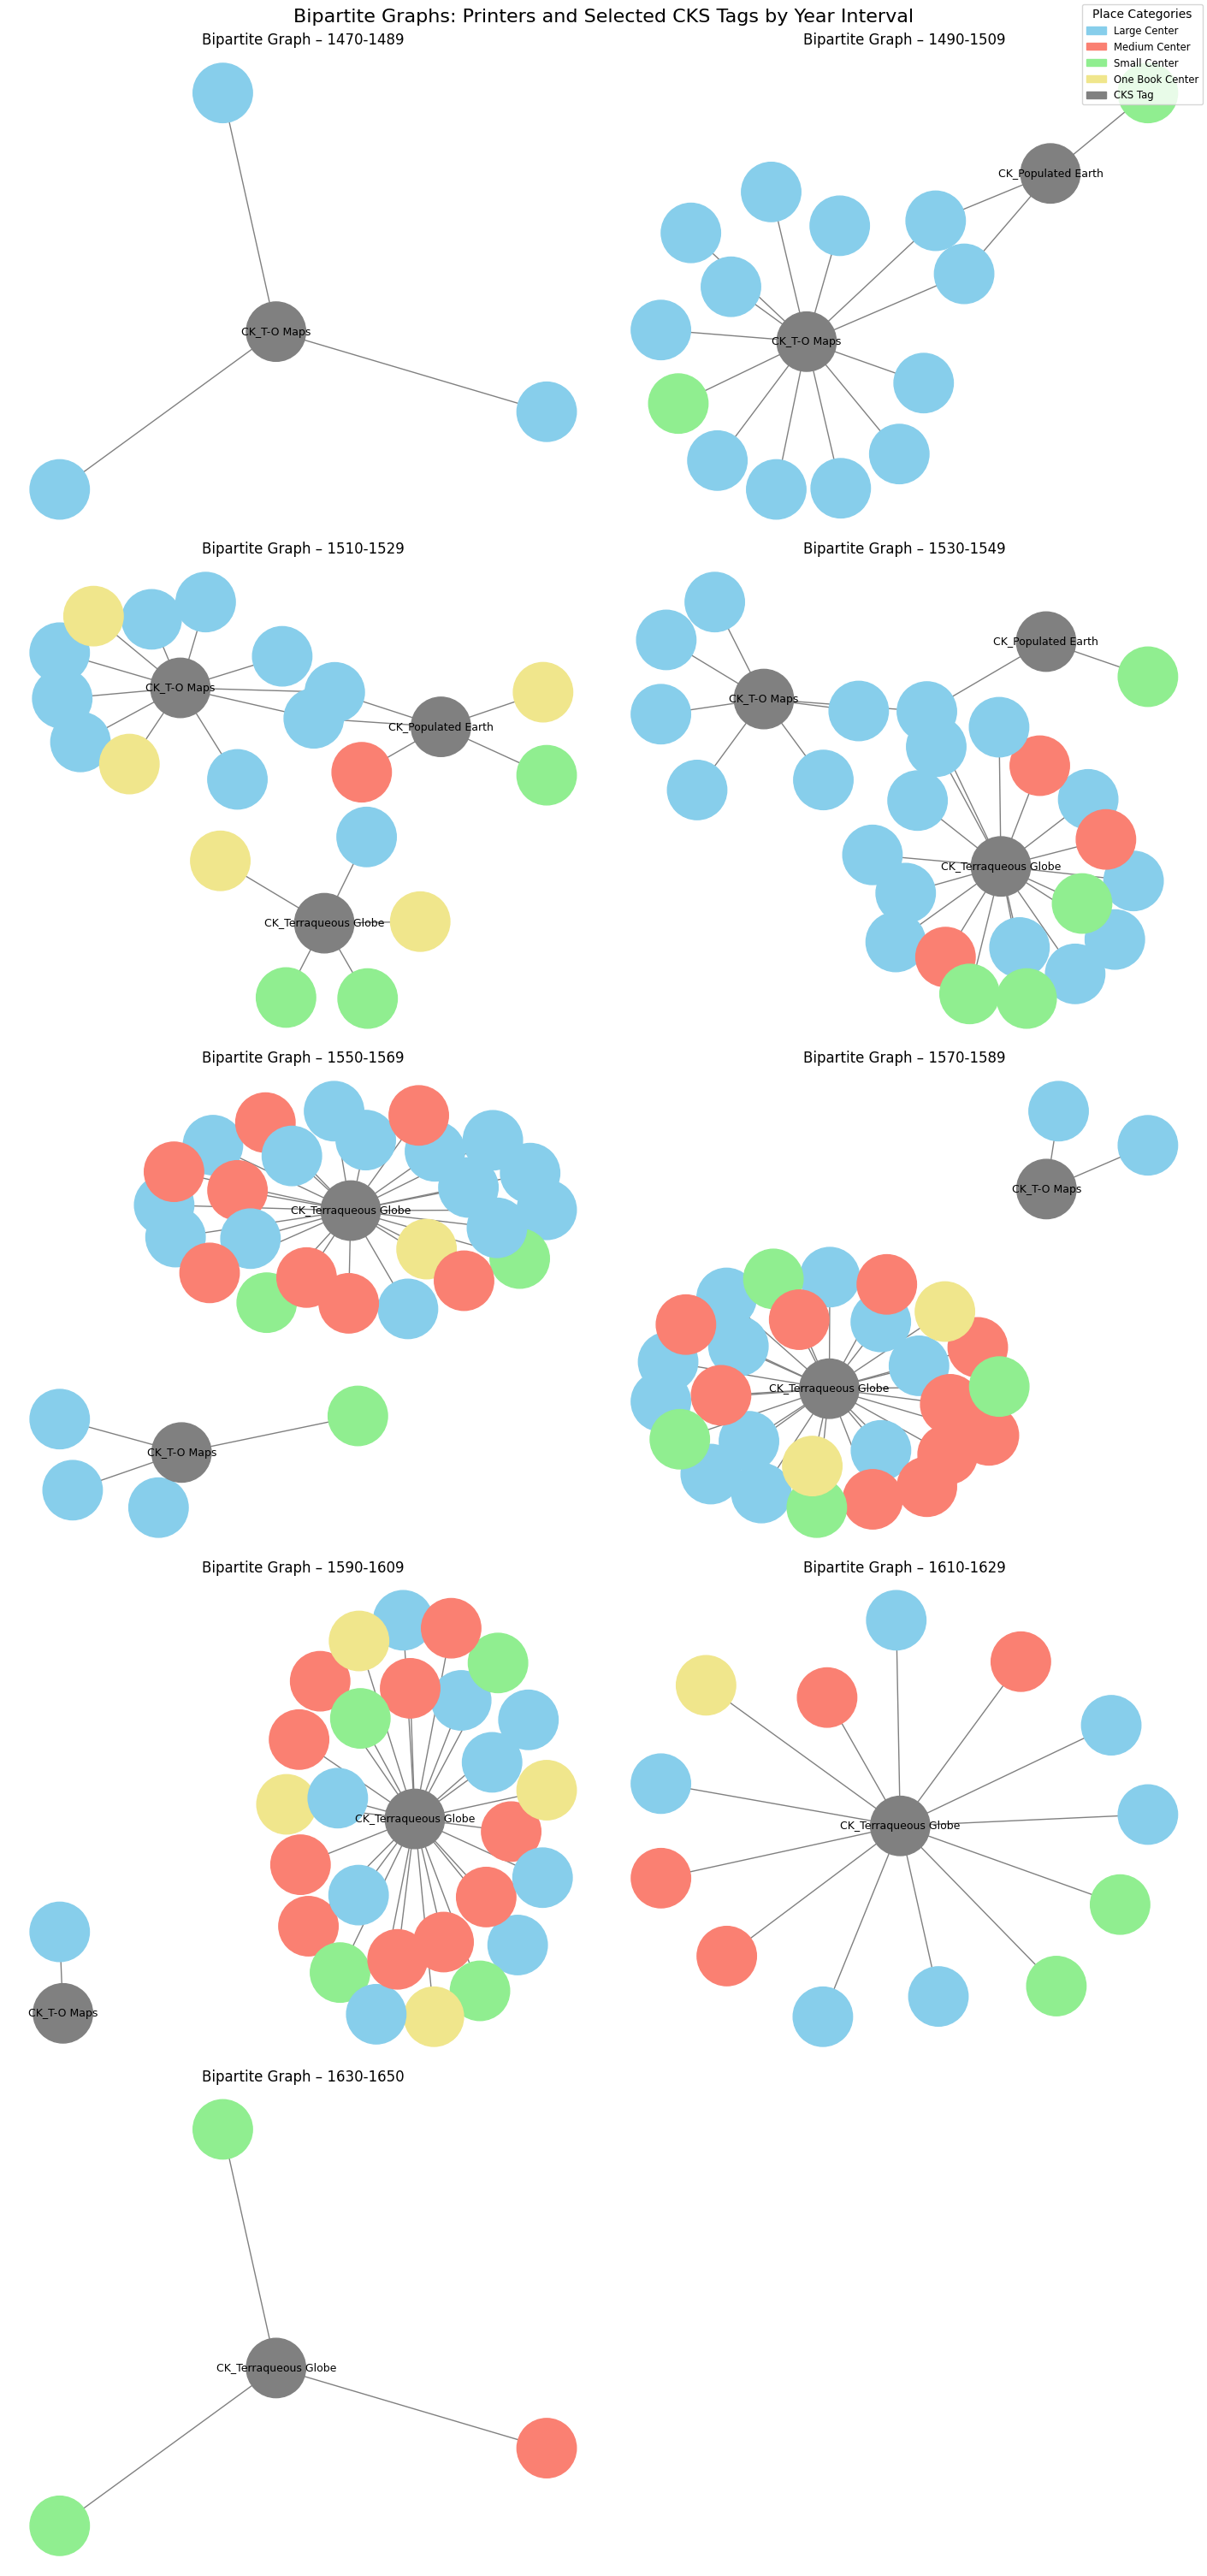

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === PARAMETERS ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}
keywords = ['CK_T-O Maps', 'CK_Populated Earth', 'CK_Terraqueous Globe']

# === FILTER TO JUST SELECTED CKS ===
subset_df = filtered_df[filtered_df['cks'].isin(keywords)].copy()

# === GET UNIQUE TIME INTERVALS ===
intervals = sorted(subset_df['year_interval'].dropna().unique())

# === CREATE SUBPLOTS ===
n_cols = 2
n_rows = (len(intervals) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows), constrained_layout=True)
axes = axes.flatten()

# === LOOP OVER EACH TIME INTERVAL ===
for i, interval in enumerate(intervals):
    ax = axes[i]
    df_interval = subset_df[subset_df['year_interval'] == interval].copy()

    places = df_interval['printer'].dropna().unique().tolist()
    cks_tags = df_interval['cks'].dropna().unique().tolist()

    # Build edges
    edges = []
    for place in places:
        place_data = df_interval[df_interval['printer'] == place]
        for cks in cks_tags:
            if (place_data['cks'] == cks).any():
                edges.append((place, cks))
    edges_df = pd.DataFrame(edges, columns=['printer', 'cks']).drop_duplicates()

    # Place color mapping
    place_color_map = {
        place: category_color_map.get(
            filtered_df[filtered_df['printer'] == place]['place_category'].iloc[0],
            'gray'
        )
        for place in places
    }

    # Build graph
    G = nx.Graph()
    G.add_nodes_from(places, bipartite=0)
    G.add_nodes_from(cks_tags, bipartite=1)
    G.add_edges_from(edges_df.itertuples(index=False, name=None))

    # Node colors
    node_colors = [
        place_color_map.get(node, 'gray') if node in places else 'gray'
        for node in G.nodes()
    ]

    # Label only CKS nodes
    labels = {node: node for node in cks_tags}

    pos = nx.spring_layout(G, seed=42, k=0.5)

    # Draw graph
    nx.draw(
        G, pos,
        labels=labels,
        node_color=node_colors,
        edge_color='gray',
        node_size=2500,
        font_size=9,
        ax=ax
    )

    ax.set_title(f"Bipartite Graph – {interval}", fontsize=12)
    ax.axis('off')

# === REMOVE EMPTY AXES IF NEEDED ===
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === LEGEND ===
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='gray', label='CKS Tag'))

fig.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.suptitle("Bipartite Graphs: Printers and Selected CKS Tags by Year Interval", fontsize=16)
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_nested_spheres_by_interval.png', dpi=300)
plt.show()


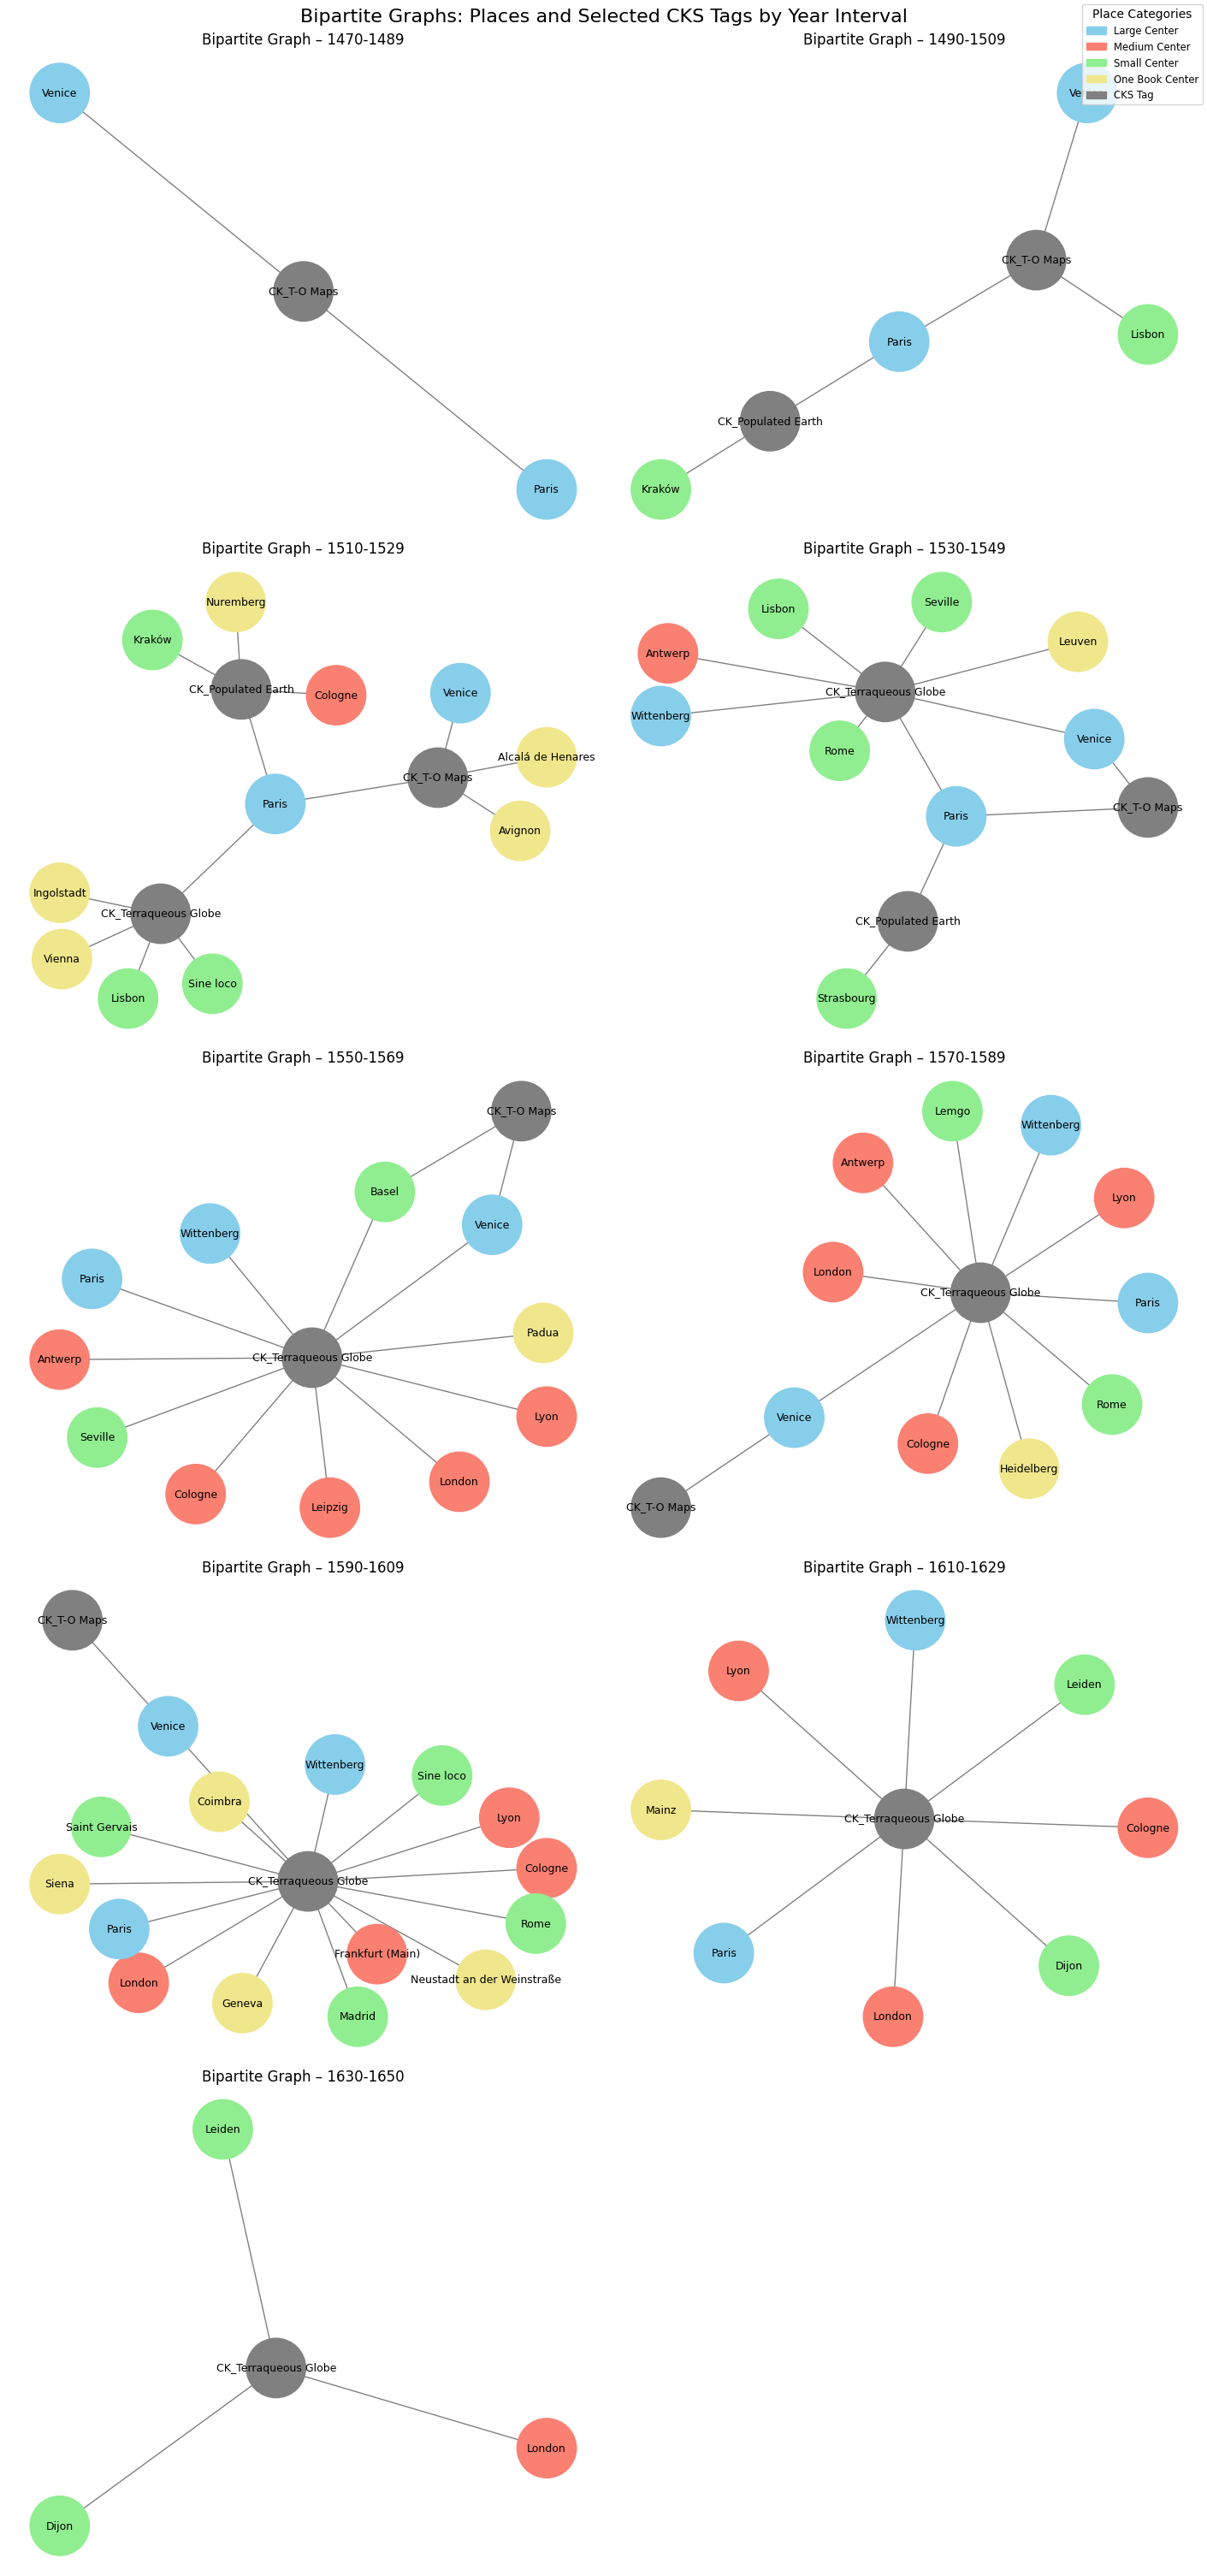

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === PARAMETERS ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}
keywords = ['CK_T-O Maps', 'CK_Populated Earth', 'CK_Terraqueous Globe']

# === FILTER TO SELECTED CKS ===
subset_df = filtered_df[filtered_df['cks'].isin(keywords)].copy()

# === GET UNIQUE TIME INTERVALS ===
intervals = sorted(subset_df['year_interval'].dropna().unique())

# === CREATE SUBPLOTS ===
n_cols = 2
n_rows = (len(intervals) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows), constrained_layout=True)
axes = axes.flatten()

# === LOOP OVER EACH TIME INTERVAL ===
for i, interval in enumerate(intervals):
    ax = axes[i]
    df_interval = subset_df[subset_df['year_interval'] == interval].copy()

    places = df_interval['place'].dropna().unique().tolist()
    cks_tags = df_interval['cks'].dropna().unique().tolist()

    # Build edges
    edges = []
    for place in places:
        place_data = df_interval[df_interval['place'] == place]
        for cks in cks_tags:
            if (place_data['cks'] == cks).any():
                edges.append((place, cks))
    edges_df = pd.DataFrame(edges, columns=['place', 'cks']).drop_duplicates()

    # Place color mapping
    place_color_map = {
        place: category_color_map.get(
            filtered_df[filtered_df['place'] == place]['place_category'].iloc[0],
            'gray'
        )
        for place in places
    }

    # Build graph
    G = nx.Graph()
    G.add_nodes_from(places, bipartite=0)
    G.add_nodes_from(cks_tags, bipartite=1)
    G.add_edges_from(edges_df.itertuples(index=False, name=None))

    # Node colors
    node_colors = [
        place_color_map.get(node, 'gray') if node in places else 'gray'
        for node in G.nodes()
    ]

    # === Label all nodes (places + CKS) ===
    labels = {node: node for node in G.nodes()}

    pos = nx.spring_layout(G, seed=42, k=0.5)

    # Draw graph with labels
    nx.draw(
        G, pos,
        labels=labels,
        node_color=node_colors,
        edge_color='gray',
        node_size=2500,
        font_size=9,
        ax=ax
    )

    ax.set_title(f"Bipartite Graph – {interval}", fontsize=12)
    ax.axis('off')

# === REMOVE EMPTY AXES IF NEEDED ===
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === LEGEND ===
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='gray', label='CKS Tag'))

fig.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.suptitle("Bipartite Graphs: Places and Selected CKS Tags by Year Interval", fontsize=16)
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_nested_spheres_places_by_interval.png', dpi=300)
plt.show()


In [33]:
# === FILTER for Terraqueous Globe entries only ===
terraqueous_df = filtered_df[filtered_df['cks'] == 'CK_Terraqueous Globe'].copy()

# Drop rows with missing year or place values
terraqueous_df = terraqueous_df.dropna(subset=['year', 'place', 'year_interval'])

# Sort for clean output
terraqueous_df = terraqueous_df.sort_values(by=['year_interval', 'year', 'place'])

# === GROUP and PRINT ===
for interval, group in terraqueous_df.groupby('year_interval'):
    print(f"\n=== {interval} ===")
    for _, row in group.iterrows():
        year = row['year']
        place = row['place']
        title = row.get('title', '')  # Optional: include title if available
        print(f"  - {year}: {place}" + (f" — {title}" if title else ""))



=== 1510-1529 ===
  - 1510: Lisbon
  - 1518: Vienna
  - 1518: Vienna
  - 1521: Sine loco
  - 1525: Paris
  - 1526: Ingolstadt

=== 1530-1549 ===
  - 1531: Wittenberg
  - 1532: Paris
  - 1532: Venice
  - 1534: Venice
  - 1534: Wittenberg
  - 1536: Wittenberg
  - 1537: Lisbon
  - 1537: Rome
  - 1537: Venice
  - 1537: Venice
  - 1538: Wittenberg
  - 1538: Wittenberg
  - 1540: Wittenberg
  - 1541: Venice
  - 1541: Venice
  - 1542: Paris
  - 1542: Paris
  - 1543: Antwerp
  - 1543: Antwerp
  - 1543: Venice
  - 1543: Wittenberg
  - 1543: Wittenberg
  - 1545: Paris
  - 1545: Seville
  - 1545: Venice
  - 1545: Wittenberg
  - 1545: Wittenberg
  - 1546: Paris
  - 1547: Antwerp
  - 1547: Antwerp
  - 1547: Leuven
  - 1548: Antwerp
  - 1548: Seville
  - 1548: Venice
  - 1549: Paris
  - 1549: Wittenberg
  - 1549: Wittenberg

=== 1550-1569 ===
  - 1550: Paris
  - 1550: Paris
  - 1550: Paris
  - 1550: Paris
  - 1550: Paris
  - 1550: Venice
  - 1550: Wittenberg
  - 1550: Wittenberg
  - 1551: Antwerp
  